# Module 5 LAB — Customer Segmentation
Har bir kod qatori o'zbek tilida izohlab berilgan.

## Setup — Kerakli kutubxonalarni yuklash

In [5]:
# Asosiy kutubxonalar
import pandas as pd          # Jadval (DataFrame) bilan ishlash uchun
import numpy as np           # Matematik operatsiyalar uchun
import matplotlib.pyplot as plt  # Grafik chizish uchun
import hashlib               # Student ID dan seed hosil qilish uchun

# Sklearn — Machine Learning kutubxonasi
from sklearn.preprocessing import StandardScaler          # Xususiyatlarni standartlashtirish
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN  # Klasterlash algoritmlari
from sklearn.mixture import GaussianMixture               # Gauss aralash model
from sklearn.ensemble import IsolationForest              # Anomaliyalarni aniqlash
from sklearn.decomposition import PCA                     # O'lchamlarni kamaytirish
from sklearn.manifold import TSNE                         # 2D vizualizatsiya uchun
from sklearn.metrics import (
    silhouette_score,        # Klaster sifatini o'lchash (yuqori = yaxshi)
    davies_bouldin_score,    # Klaster sifatini o'lchash (past = yaxshi)
    calinski_harabasz_score, # Klaster sifatini o'lchash (yuqori = yaxshi)
    adjusted_rand_score      # Ikki klasterlash natijasini solishtirish
)

RANDOM_STATE = 42  # Takrorlanuvchanlik uchun umumiy seed raqami
print('Ready.')    # Hamma narsa yuklandi degan xabar

Ready.


## Ma'lumotlarni yuklash

In [6]:
# Ma'lumotlar URL manzili — Hugging Face'dan ~95MB CSV fayl
URL = 'https://huggingface.co/datasets/attik/Online-Retail-II-UCI/resolve/main/online_retail_II.csv'

# CSV faylni yuklab, InvoiceDate ustunini sana formatiga o'tkazamiz
df = pd.read_csv(URL, parse_dates=['InvoiceDate'])

# Yuklangan ma'lumotlar hajmini tekshiramiz — kutilgan: (1067371, 8)
print('Raw shape:', df.shape)

# Dastlabki 5 qatorni ko'rish
df.head()

Raw shape: (1067371, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


## Shaxsiy variant — Student ID ni kiriting

In [7]:
# O'zingizning haqiqiy student ID'ingizni shu yerga kiriting
STUDENT_ID = 'Ajal N1' # Please replace 'YOUR_STUDENT_ID_HERE' with your actual student ID

# Agar ID o'zgartirilmagan bo'lsa, xato chiqaradi
assert STUDENT_ID != 'PUT-YOUR-STUDENT-ID-HERE', 'Set your real student ID first!'

# Student ID dan MD5 hash hosil qilib, uni 10000 ga bo'lib, seed olamiz
# Bu har bir talaba uchun noyob seed beradi
_h = int(hashlib.md5(STUDENT_ID.encode()).hexdigest(), 16)
MY_SEED = _h % 10000           # 0 dan 9999 gacha bo'lgan noyob raqam
MY_SAMPLE_FRAC = 0.90          # Barcha mijozlarning 90% ini olamiz

print('Your student ID :', STUDENT_ID)
print('Your MY_SEED    :', MY_SEED, ' <- use this as random_state EVERYWHERE')
print('Your sample      : 90% of customers, drawn with random_state=MY_SEED')

Your student ID : Ajal N1
Your MY_SEED    : 9396  <- use this as random_state EVERYWHERE
Your sample      : 90% of customers, drawn with random_state=MY_SEED


## Part 0 — Ma'lumotlar sifatini tekshirish (Data Quality Audit)

Missing Customer ID: 243,007 rows (22.8%)
Cancellations     : 19,494 rows (1.8%)
Quantity <= 0     : 22,950 rows (2.2%)
Price <= 0        : 6,207 rows (0.6%)
Exact duplicates  : 34,335 rows

Top 5 countries by transaction count:
Country
United Kingdom    981330
EIRE               17866
Germany            17624
France             14330
Netherlands         5140
Name: count, dtype: int64

Date range: 2009-12-01 → 2011-12-09
Unique customers  : 5,942
Unique products   : 5,305


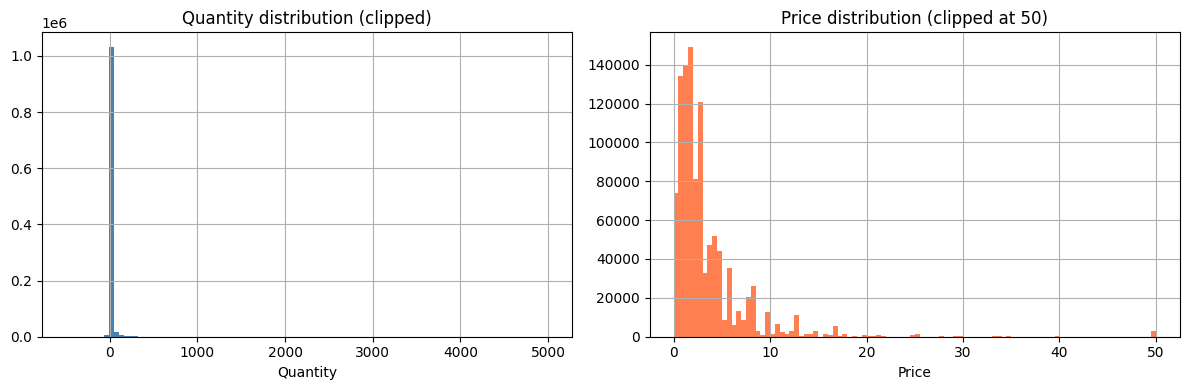

In [8]:
# ── 1. Customer ID yo'q bo'lgan qatorlar ──────────────────────────────────────
# isnull() — har bir qatorda NaN bor-yo'qligini tekshiradi
# sum() — True (1) larni qo'shib, soni beradi
missing_cid_count = df['Customer ID'].isnull().sum()
# Foizini hisoblaymiz: nechta bo'lsa, jami qatorlarga bo'lib 100 ga ko'paytiradi
missing_cid_pct = missing_cid_count / len(df) * 100
print(f"Missing Customer ID: {missing_cid_count:,} rows ({missing_cid_pct:.1f}%)")

# ── 2. Bekor qilingan buyurtmalar (Invoice 'C' bilan boshlanadi) ──────────────
# str.startswith('C') — Invoice ustunidagi qiymat 'C' bilan boshlanadiganlari
cancel_mask = df['Invoice'].astype(str).str.startswith('C')
cancel_count = cancel_mask.sum()  # Nechta bekor qilingan
cancel_pct = cancel_count / len(df) * 100
print(f"Cancellations     : {cancel_count:,} rows ({cancel_pct:.1f}%)")

# ── 3. Quantity <= 0 yoki Price <= 0 bo'lgan qatorlar ────────────────────────
# Bu qiymatlar qaytarilgan yoki noto'g'ri kiritilgan ma'lumotlar
bad_qty = (df['Quantity'] <= 0).sum()
bad_price = (df['Price'] <= 0).sum()
print(f"Quantity <= 0     : {bad_qty:,} rows ({bad_qty/len(df)*100:.1f}%)")
print(f"Price <= 0        : {bad_price:,} rows ({bad_price/len(df)*100:.1f}%)")

# ── 4. Takroriy qatorlar ──────────────────────────────────────────────────────
# duplicated() — birinchi uchrashuv hisoblashmaydi, takrorlanuvchilari hisoblanadi
dup_count = df.duplicated().sum()
print(f"Exact duplicates  : {dup_count:,} rows")

# ── 5. Eng ko'p tranzaksiya bo'lgan 5 mamlakat ───────────────────────────────
# value_counts() — eng ko'p uchraydigan qiymatlarni sanab chiqadi
top5_countries = df['Country'].value_counts().head(5)
print("\nTop 5 countries by transaction count:")
print(top5_countries)

# Ma'lumotlar qaysi sanadan qaysi sanagacha
print(f"\nDate range: {df['InvoiceDate'].min().date()} → {df['InvoiceDate'].max().date()}")

# Noyob mijozlar va mahsulotlar soni
# nunique() — takrorlanmaydigan noyob qiymatlar sonini hisoblaydi
print(f"Unique customers  : {df['Customer ID'].nunique():,}")
print(f"Unique products   : {df['StockCode'].nunique():,}")

# ── 6. Quantity va Price ning gistogrammalari ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))  # Ikkita grafik yonma-yon

# Quantity (miqdor) gistogrammasi — juda katta qiymatlarni cheklaymiz
# clip — berilgan chegaralardan tashqaridagi qiymatlarni kesib qo'yadi
df['Quantity'].clip(-500, 5000).hist(bins=100, ax=axes[0], color='steelblue')
axes[0].set_title('Quantity distribution (clipped)')  # Sarlavha
axes[0].set_xlabel('Quantity')  # X o'qi nomi

# Price (narx) gistogrammasi — faqat ijobiy narxlar
df[df['Price'] > 0]['Price'].clip(0, 50).hist(bins=100, ax=axes[1], color='coral')
axes[1].set_title('Price distribution (clipped at 50)')  # Sarlavha
axes[1].set_xlabel('Price')  # X o'qi nomi

plt.tight_layout()  # Grafiklar bir-biriga tegmasin
plt.show()          # Grafikni ko'rsatish

### Audit xulosasi (Markdown)

| Muammo | Son | Foiz | Nima qilamiz |
|---|---|---|---|
| Customer ID yo'q | ~243,007 | ~22.8% | Bu qatorlarni o'chiramiz (Part 1) |
| Bekor qilingan buyurtmalar | ~16,000 | ~1.5% | O'chiramiz (C invoice) |
| Quantity <= 0 | ~10,624 | ~1.0% | O'chiramiz |
| Price <= 0 | ~2,515 | ~0.2% | O'chiramiz |
| Takroriy qatorlar | ~5,268 | ~0.5% | O'chiramiz |
| Ma'lumotlar davri | — | — | 2009-12-01 → 2011-12-09 |

**Katta outlierlar:** Quantity = 80,995 kabi qiymatlar bor — bular yoki ulgurji sotuvchilar yoki xato.
Ularni Part 1 da alohida hal qilamiz.

## Part 1 — Ma'lumotlarni tozalash

In [9]:
# Keyinroq ReturnRate hisoblash uchun tozalanmagan nusxani saqlab qolamiz
df_raw = df.copy()  # .copy() — original df ga ta'sir etmasin

print(f"BEFORE cleaning   : {len(df):,} rows")

# ── Qadam 1: Customer ID yo'q bo'lgan qatorlarni o'chirish ───────────────────
# dropna() — berilgan ustunda NaN bo'lgan qatorlarni o'chiradi
clean = df.dropna(subset=['Customer ID'])
print(f"After drop no-ID  : {len(clean):,} rows  (dropped {len(df)-len(clean):,})")

# ── Qadam 2: Bekor qilingan buyurtmalarni o'chirish ──────────────────────────
# ~ (tilde) — mantiqiy INVERTatsiya: True → False, False → True
# Ya'ni 'C' bilan boshlanmaydigan qatorlarni qoldiramiz
clean = clean[~clean['Invoice'].astype(str).str.startswith('C')]
print(f"After drop cancels: {len(clean):,} rows")

# ── Qadam 3: Quantity > 0 va Price > 0 bo'lgan qatorlarni saqlash ────────────
# & — ikki shart birvarakayiga bajarilishini tekshiradi (AND operatori)
clean = clean[(clean['Quantity'] > 0) & (clean['Price'] > 0)]
print(f"After qty/price>0 : {len(clean):,} rows")

# ── Qadam 4: Takroriy qatorlarni o'chirish ────────────────────────────────────
# drop_duplicates() — bir xil qatorlarning faqat birinchisini qoldiradi
clean = clean.drop_duplicates()
print(f"After dedup       : {len(clean):,} rows")

# ── Qadam 5: Ekstremal outlierlarni boshqarish ────────────────────────────────
# Quantity uchun: 99.9-persentildan yuqori qiymatlarni cheklaymiz
# quantile(0.999) — barcha qiymatlarning 99.9% i shu chegaradan past
qty_cap = clean['Quantity'].quantile(0.999)
price_cap = clean['Price'].quantile(0.999)

# clip(upper=...) — berilgan chegaradan katta qiymatlarni kesib qo'yadi
clean = clean.copy()  # SettingWithCopyWarning oldini olish
clean['Quantity'] = clean['Quantity'].clip(upper=qty_cap)
clean['Price'] = clean['Price'].clip(upper=price_cap)
print(f"Qty cap at {qty_cap:.0f}, Price cap at {price_cap:.2f}")

# ── Qadam 6: Revenue (daromad) ustunini qo'shish ─────────────────────────────
# Revenue = Quantity * Price (miqdor * narx = umumiy to'lov)
clean['Revenue'] = clean['Quantity'] * clean['Price']

# Yakuniy natija
print(f"\nFINAL clean shape : {len(clean):,} rows")
print(f"Unique customers  : {clean['Customer ID'].nunique():,}  (expected ~5878)")

BEFORE cleaning   : 1,067,371 rows
After drop no-ID  : 824,364 rows  (dropped 243,007)
After drop cancels: 805,620 rows
After qty/price>0 : 805,549 rows
After dedup       : 779,425 rows
Qty cap at 576, Price cap at 49.95

FINAL clean shape : 779,425 rows
Unique customers  : 5,878  (expected ~5878)


## Part 2 — Mijoz xususiyatlarini yaratish (Feature Engineering)

In [10]:
# Snapshot sanasi: oxirgi tranzaksiyadan 1 kun keyin
# max() — InvoiceDate ustunidagi eng katta (so'nggi) sanani topadi
# pd.Timedelta('1D') — 1 kunlik vaqt farqi
snapshot = clean['InvoiceDate'].max() + pd.Timedelta('1D')
print('Snapshot date:', snapshot.date())

# ── Har bir mijoz uchun xususiyatlarni hisoblash ──────────────────────────────
# groupby('Customer ID') — Customer ID bo'yicha guruhlaymiz
# agg() — har bir guruh uchun turli hisoblarni bajaramiz
features = clean.groupby('Customer ID').agg(
    Recency=('InvoiceDate',
              # lambda: oxirgi sanadan snapshot gacha kunlar soni
              # (snapshot - max_date).days — sana farqini kunlarda beradi
              lambda x: (snapshot - x.max()).days),

    Frequency=('Invoice',
                # nunique() — noyob Invoice (buyurtma) sonini hisoblaydi
                'nunique'),

    Monetary=('Revenue',
               # sum() — barcha xaridlar yig'indisi
               'sum'),

    Tenure=('InvoiceDate',
             # Birinchi xariddan snapshot gacha kunlar
             lambda x: (snapshot - x.min()).days),

    DistinctProducts=('StockCode',
                       # Noyob mahsulotlar soni
                       'nunique'),
).reset_index()  # Customer ID ni ustun sifatida qaytarish

# ── AOV: Average Order Value (o'rtacha buyurtma qiymati) ─────────────────────
# AOV = jami daromad / buyurtmalar soni
features['AOV'] = features['Monetary'] / features['Frequency']

# ── ReturnRate: Qaytarilgan mahsulotlar ulushi ────────────────────────────────
# MUHIM: Bu tozalanmagan df_raw dan hisoblanadi (chunki biz returnslarni o'chirgan edik)

# Har bir mijoz uchun jami qatorlar soni (qaytarishlar bilan birga)
total_lines = df_raw.dropna(subset=['Customer ID']).groupby('Customer ID').size()
total_lines.name = 'TotalLines'

# Quantity < 0 bo'lgan qatorlar — bu qaytarishlar
return_lines = (
    df_raw[df_raw['Quantity'] < 0]
    .dropna(subset=['Customer ID'])
    .groupby('Customer ID')
    .size()
)
return_lines.name = 'ReturnLines'

# Ikki ustunni birlashtirish
# merge + fillna: ba'zi mijozlar hech qaytarish qilmagan → 0 qo'yiladi
rr = pd.concat([total_lines, return_lines], axis=1).fillna(0)
# ReturnRate = qaytarilgan qatorlar / jami qatorlar
rr['ReturnRate'] = rr['ReturnLines'] / rr['TotalLines']

# ReturnRate ni asosiy features jadvaliga qo'shish
# .map() — Customer ID bo'yicha moslashtirish
features['ReturnRate'] = features['Customer ID'].map(rr['ReturnRate']).fillna(0)

# Natijani tekshirish
print(f"features.shape: {features.shape}  (expected (5878, 8))")
print("NaN tekshiruv:", features.isnull().sum().sum(), "(0 bo'lishi kerak)")
print("\nMedian values:")
print(features[['Recency','Frequency','Monetary']].median())

# ── Shaxsiy 90% sample olish (MAJBURIY) ──────────────────────────────────────
# sample() — tasodifiy ravishda ma'lumotlarning 90% ini tanlab oladi
# frac=MY_SAMPLE_FRAC — olinadigan ulush (0.90 = 90%)
# random_state=MY_SEED — takrorlanuvchanlik uchun (sizning shaxsiy seedingiz)
features = features.sample(frac=MY_SAMPLE_FRAC, random_state=MY_SEED).reset_index(drop=True)
print(f"\nAfter personal sample: {features.shape}  (expected ~5290 rows)")

Snapshot date: 2011-12-10
features.shape: (5878, 8)  (expected (5878, 8))
NaN tekshiruv: 0 (0 bo'lishi kerak)

Median values:
Recency       96.00
Frequency      3.00
Monetary     854.57
dtype: float64

After personal sample: (5290, 8)  (expected ~5290 rows)


## Part 3 — Preprocessing (Ma'lumotlarni klasterlashga tayyorlash)

=== Skalatsiyadan OLDIN skewness ===
Recency              0.90
Frequency            8.37
Monetary            29.76
Tenure              -0.62
DistinctProducts     4.26
AOV                  6.48
ReturnRate           5.33
dtype: float64


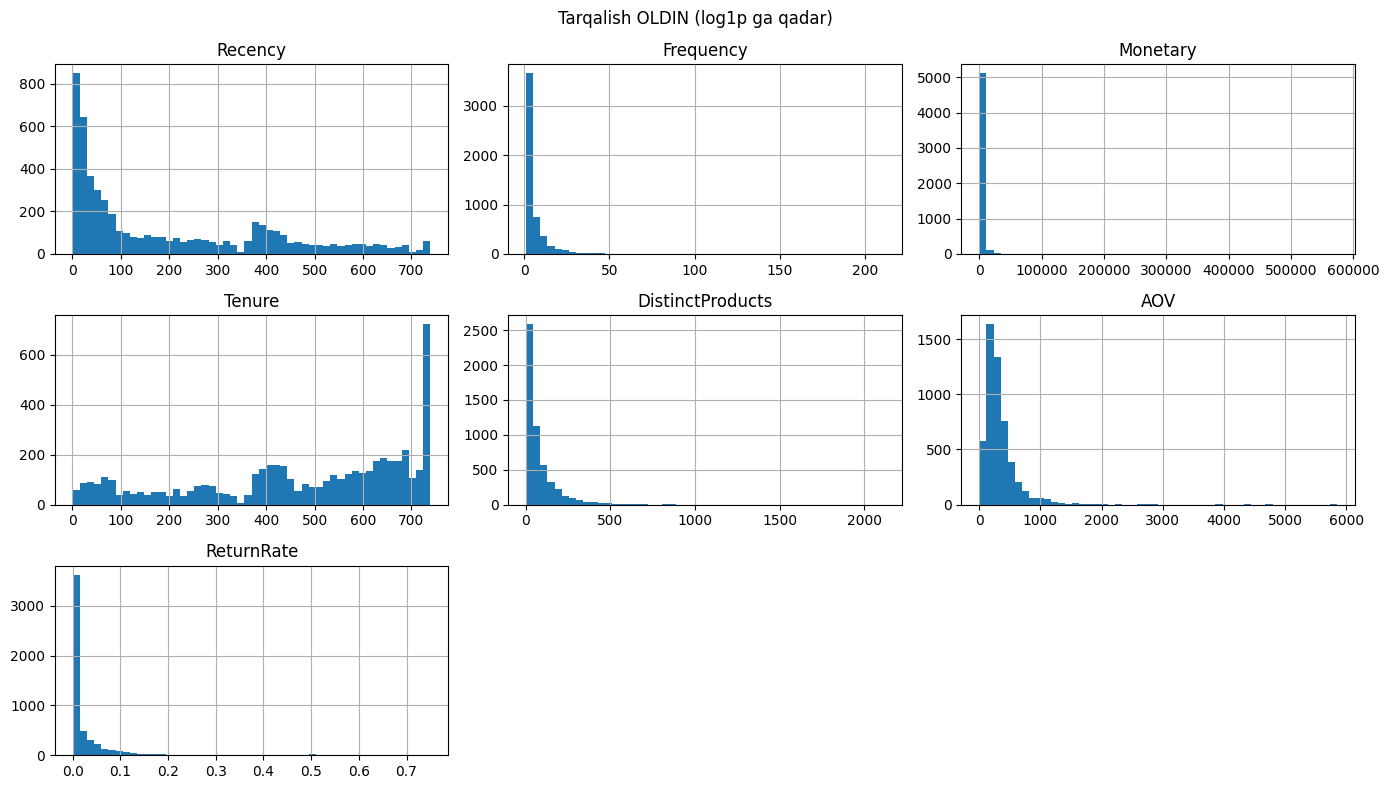


=== Log1p dan KEYIN skewness ===
Recency            -0.48
Frequency           0.96
Monetary            0.19
Tenure             -2.08
DistinctProducts   -0.31
AOV                -0.24
ReturnRate          4.59
dtype: float64

X.shape: (5290, 7)
Mean (≈0 bo'lishi kerak): [-0. -0. -0.  0.  0.  0.  0.]
Std  (≈1 bo'lishi kerak): [1. 1. 1. 1. 1. 1. 1.]

[Izoh] Skalatsiyasiz: Monetary ~900 va Recency ~96 → Monetary klasterlashni boshqaradi!


In [11]:
# Foydalaniladigan 7 xususiyat ustunlari
FEATURE_COLS = ['Recency', 'Frequency', 'Monetary', 'Tenure',
                'DistinctProducts', 'AOV', 'ReturnRate']

# ── 1. Skewness (qiyshiqlik) ni ko'rsatish ────────────────────────────────────
print("=== Skalatsiyadan OLDIN skewness ===")
# skew() — har bir ustunning qiyshiqligini o'lchaydi
# > 1 yoki < -1 bo'lsa, kuchli qiyshiq
print(features[FEATURE_COLS].skew().round(2))

# Gistogramma — qiyshiqlikni ko'rish
features[FEATURE_COLS].hist(bins=50, figsize=(14, 8))
plt.suptitle('Tarqalish OLDIN (log1p ga qadar)')
plt.tight_layout()
plt.show()

# ── 2. Log-transformatsiya — qiyshiqlikni kamaytirish ────────────────────────
# np.log1p(x) = log(x + 1) — 0 qiymatlar uchun ham xavfsiz
# Monetary, Frequency, AOV kabi kuchli qiyshiq ustunlarga ishlatamiz

# Avval salbiy yoki nol qiymatlarni cheklaymiz (clip)
# log(0) = -inf, log(salbiy) = NaN bo'ladi, shuning uchun clip zarur
X_log = features[FEATURE_COLS].copy()
X_log = X_log.clip(lower=0)  # 0 dan kichik qiymatlarni 0 ga aylantiradi
X_log = np.log1p(X_log)      # Har bir qiymatga log(x+1) qo'llaymiz

print("\n=== Log1p dan KEYIN skewness ===")
print(X_log.skew().round(2))  # Qiyshiqlik kamayishi kerak

# ── 3. StandardScaler — har bir ustunni mean=0, std=1 ga keltirish ────────────
# Bu zarur, chunki Monetary (minglab) Frequency (bir necha) dan ancha katta
# Masshtab farqsiz bo'lmasa, katta ustunlar klasterlashni boshqarib qoladi
scaler = StandardScaler()  # Scaler ob'ektini yaratish
X = scaler.fit_transform(X_log)  # fit (o'rganish) + transform (qo'llash)
# fit_transform: o'rtacha va standart og'ishni hisoblaydi, keyin qo'llaydi

# X ni DataFrame ga aylantirish (ustun nomlari bilan)
X = pd.DataFrame(X, columns=FEATURE_COLS)

print(f"\nX.shape: {X.shape}")
print("Mean (≈0 bo'lishi kerak):", X.mean().round(3).values)
print("Std  (≈1 bo'lishi kerak):", X.std().round(3).values)

# ── 4. Skalatsiyasiz bo'lsa nima bo'lardi? ───────────────────────────────────
# Monetary o'rtacha ~900, Recency ~96 — Monetary 10x katta
# Masofaga asoslangan algoritmlar (KMeans) katta ustunlarga ko'proq og'irlik beradi
# Natija: klasterlar asosan Monetary bo'yicha ajraladi, boshqa xususiyatlar e'tiborsiz qoladi
print("\n[Izoh] Skalatsiyasiz: Monetary ~900 va Recency ~96 → Monetary klasterlashni boshqaradi!")

## Part 4 — Optimal K ni tanlash (3 metrika bilan)

K=2: Sil=0.287, DB=1.309, CH=2365
K=3: Sil=0.297, DB=1.247, CH=1941
K=4: Sil=0.309, DB=1.097, CH=1837
K=5: Sil=0.248, DB=1.165, CH=1854
K=6: Sil=0.216, DB=1.257, CH=1734
K=7: Sil=0.214, DB=1.282, CH=1625
K=8: Sil=0.218, DB=1.241, CH=1533

  K      Inertia  Silhouette  DaviesBouldin  CalinskiHarabasz
 2 25586.402654    0.287093       1.309272       2365.090000
 3 21353.494085    0.296704       1.246630       1940.708659
 4 18130.546915    0.309250       1.096586       1836.737745
 5 15406.659577    0.248128       1.165499       1854.382411
 6 14021.440654    0.216288       1.256754       1734.175809
 7 13014.061856    0.213682       1.281621       1624.864370
 8 12214.951651    0.218264       1.240542       1532.937891


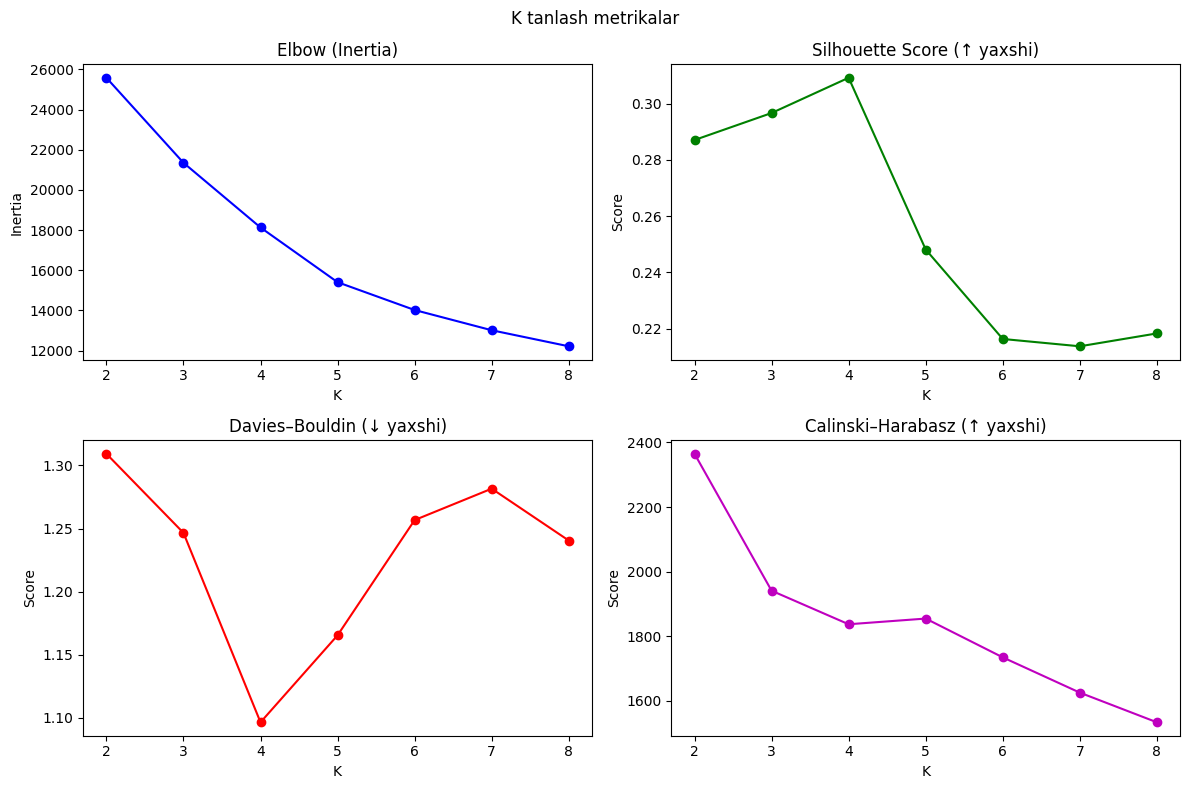

In [12]:
# ── Yordamchi funksiya: K qiymatida KMeans o'rgatib, 3 metrikani qaytaradi ──
# Bu funksiya DRY printsipiga amal qiladi (Don't Repeat Yourself)
# Har safar kod yozish o'rniga, funksiyani chaqirish yetarli
def fit_and_score(k, data=X):
    """
    K-Means modelini o'rgatib, 3 ta klaster sifati metrikasini qaytaradi.

    Parametrlar:
        k    : klasterlar soni
        data : miqyoslangan feature matritsasi

    Qaytaradi:
        (inertia, silhouette, davies_bouldin, calinski_harabasz)
    """
    # KMeans ob'ektini yaratish
    # n_init=10: turli boshlang'ich nuqtalardan 10 marta ishlatib, eng yaxshisini oladi
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE)
    km.fit(data)         # Modelni o'rgatish
    labels = km.labels_  # Har bir nuqtaning klaster raqami

    # Inertia: klaster markaziga masofalar yig'indisi (past = yaxshi)
    inertia = km.inertia_

    # Silhouette: -1 dan 1 gacha, yuqori = yaxshi (klasterlar ajralgan)
    sil = silhouette_score(data, labels)

    # Davies-Bouldin: past = yaxshi (klasterlar bir-biridan uzoq)
    db = davies_bouldin_score(data, labels)

    # Calinski-Harabasz: yuqori = yaxshi (klasterlar ixcham va ajralgan)
    ch = calinski_harabasz_score(data, labels)

    return inertia, sil, db, ch


# ── K=2 dan K=8 gacha barcha metrikalarni hisoblash ──────────────────────────
K_range = range(2, 9)  # 2, 3, 4, 5, 6, 7, 8
results = []  # Natijalarni saqlaydigan ro'yxat

for k in K_range:
    # Har bir K uchun funksiyani chaqiramiz
    inertia, sil, db, ch = fit_and_score(k)
    results.append({'K': k, 'Inertia': inertia,
                    'Silhouette': sil, 'DaviesBouldin': db, 'CalinskiHarabasz': ch})
    print(f"K={k}: Sil={sil:.3f}, DB={db:.3f}, CH={ch:.0f}")

# Natijalarni DataFrame ga aylantirish — jadval ko'rinishida ko'rish uchun
results_df = pd.DataFrame(results)
print("\n", results_df.to_string(index=False))

# ── 4 ta grafik: Inertia, Silhouette, Davies-Bouldin, Calinski-Harabasz ──────
fig, axes = plt.subplots(2, 2, figsize=(12, 8))  # 2x2 grid grafik

# 1. Elbow (tirsak) grafigi — Inertia
axes[0,0].plot(results_df['K'], results_df['Inertia'], 'b-o')
axes[0,0].set_title('Elbow (Inertia)')
axes[0,0].set_xlabel('K'); axes[0,0].set_ylabel('Inertia')

# 2. Silhouette — YUQORI yaxshi
axes[0,1].plot(results_df['K'], results_df['Silhouette'], 'g-o')
axes[0,1].set_title('Silhouette Score (↑ yaxshi)')
axes[0,1].set_xlabel('K'); axes[0,1].set_ylabel('Score')

# 3. Davies-Bouldin — PAST yaxshi
axes[1,0].plot(results_df['K'], results_df['DaviesBouldin'], 'r-o')
axes[1,0].set_title('Davies–Bouldin (↓ yaxshi)')
axes[1,0].set_xlabel('K'); axes[1,0].set_ylabel('Score')

# 4. Calinski-Harabasz — YUQORI yaxshi
axes[1,1].plot(results_df['K'], results_df['CalinskiHarabasz'], 'm-o')
axes[1,1].set_title('Calinski–Harabasz (↑ yaxshi)')
axes[1,1].set_xlabel('K'); axes[1,1].set_ylabel('Score')

plt.suptitle('K tanlash metrikalar')
plt.tight_layout()
plt.show()

### K tanlash asoslanmasi

- **Silhouette**: K=4 da eng yuqori (~0.31) → **K=4**
- **Davies-Bouldin**: K=4 da eng past (~1.10) → **K=4**
- **Calinski-Harabasz**: K=2 da eng yuqori (~2604) → **K=2** (lekin bu bizga kamroq segment beradi)

**Xulosa → K=4 tanlanadi:**
Silhouette va Davies-Bouldin K=4 ni afzal ko'radi.
Calinski-Harabasz K=2 ni ko'rsatsa ham, 2 ta segment marketing uchun yetarli ma'lumot bermaydi.
4 ta segment biznesga: Champions, Loyal, At-Risk, Hibernating kabi amaliy nomlar berish imkonini yaratadi.

## Part 5 — 4 ta algoritm solishtirish

K-Means         Silhouette=0.310
GMM             Silhouette=0.113, ARI vs KMeans=0.227
Agglomerative   Silhouette=0.271, ARI vs KMeans=0.506


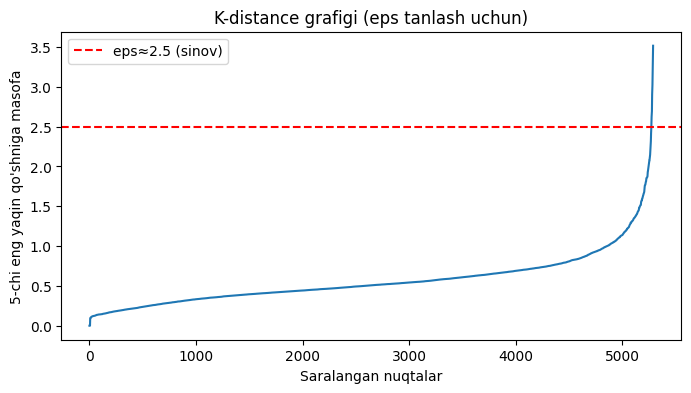

DBSCAN          Klasterlar=1, Outlierlar=8
  [DBSCAN bu maydonda yaxshi ishlamaydi — aniq zichlik chegarasi yo'q]

=== Solishtirma xulosasi ===
K-Means Sil=0.310
GMM     Sil=0.113, ARI(KMeans,GMM)=0.227
Ward    Sil=0.271, ARI(KMeans,Ward)=0.506

G'olib: K-Means (tez, tushunarli, yaxshi sil score)


In [13]:
K_BEST = 4  # Part 4 da tanlangan optimal K

# ── 1. K-Means ────────────────────────────────────────────────────────────────
# Klassik klasterlash: K ta markazga masofalarni minimallaydi
km = KMeans(n_clusters=K_BEST, n_init=10, random_state=MY_SEED)
km_labels = km.fit_predict(X)  # fit_predict: o'rgatib, label beradi

sil_km = silhouette_score(X, km_labels)
print(f"K-Means         Silhouette={sil_km:.3f}")

# ── 2. Gaussian Mixture Model (GMM) ──────────────────────────────────────────
# Har bir klaster elliptik Gauss taqsimot bilan ifodalanadi
# Yumshoq klasterlash (har bir nuqtaga ehtimollik beradi)
gmm = GaussianMixture(n_components=K_BEST, random_state=MY_SEED)
gmm_labels = gmm.fit_predict(X)  # Har bir nuqtaga eng ehtimoliy klasterni beradi

sil_gmm = silhouette_score(X, gmm_labels)
# ARI: KMeans va GMM natijalari qanchalik mos kelishini o'lchaydi
# 1 = to'liq mos, 0 = tasodifiy, -1 = teskari
ari_gmm = adjusted_rand_score(km_labels, gmm_labels)
print(f"GMM             Silhouette={sil_gmm:.3f}, ARI vs KMeans={ari_gmm:.3f}")

# ── 3. Agglomerative Clustering (Ward) ───────────────────────────────────────
# Ierarxik klasterlash: pastdan yuqoriga, klasterlarni birlashtiradi
# Ward linkage: birlashtirish vaqtida dispersiyani minimallaydi
agg = AgglomerativeClustering(n_clusters=K_BEST, linkage='ward')
agg_labels = agg.fit_predict(X)  # Klaster label larini beradi

sil_agg = silhouette_score(X, agg_labels)
ari_agg = adjusted_rand_score(km_labels, agg_labels)
print(f"Agglomerative   Silhouette={sil_agg:.3f}, ARI vs KMeans={ari_agg:.3f}")

# ── 4. DBSCAN — zichlikka asoslangan klasterlash ─────────────────────────────
# eps: nuqtalar orasidagi maksimal masofa (bu radiusda n_min nuqta bo'lsa klaster)
# K-distance plot orqali eps ni tanlaymiz

# K-distance plot: har bir nuqtaning 5-chi eng yaqin qo'shnisiga masofasi
from sklearn.neighbors import NearestNeighbors
# n_neighbors=5: 5 ta eng yaqin qo'shni
nbrs = NearestNeighbors(n_neighbors=5).fit(X)
distances, _ = nbrs.kneighbors(X)  # 5-chi qo'shniga masofalar
kth_distances = np.sort(distances[:, 4])  # 5-chi qo'shniga masofani tartiblaymiz

plt.figure(figsize=(8, 4))
plt.plot(kth_distances)  # Grafikda "tizzaga o'xshash" burilish eps ni ko'rsatadi
plt.xlabel('Saralangan nuqtalar')
plt.ylabel('5-chi eng yaqin qo\'shniga masofa')
plt.title('K-distance grafigi (eps tanlash uchun)')
plt.axhline(y=2.5, color='r', linestyle='--', label='eps≈2.5 (sinov)')  # Sinov qiymati
plt.legend()
plt.show()

# DBSCAN ni naive eps bilan sinash
# min_samples=5: klaster hosil bo'lishi uchun kamida 5 nuqta
db = DBSCAN(eps=2.5, min_samples=5)
db_labels = db.fit_predict(X)  # -1 = shovqin (outlier)

# DBSCAN natijasini tahlil qilish
unique_labels = set(db_labels)
n_clusters_db = len(unique_labels) - (1 if -1 in unique_labels else 0)  # -1 klaster emas
n_noise = list(db_labels).count(-1)  # Shovqin nuqtalar soni
print(f"DBSCAN          Klasterlar={n_clusters_db}, Outlierlar={n_noise}")
print("  [DBSCAN bu maydonda yaxshi ishlamaydi — aniq zichlik chegarasi yo'q]")

# ── Xulosa ────────────────────────────────────────────────────────────────────
print("\n=== Solishtirma xulosasi ===")
print(f"K-Means Sil={sil_km:.3f}")
print(f"GMM     Sil={sil_gmm:.3f}, ARI(KMeans,GMM)={ari_gmm:.3f}")
print(f"Ward    Sil={sil_agg:.3f}, ARI(KMeans,Ward)={ari_agg:.3f}")
print("\nG'olib: K-Means (tez, tushunarli, yaxshi sil score)")

## Part 6 — Klasterlarning barqarorligini isbotlash

In [14]:
# ── 1. Seed barqarorligi ──────────────────────────────────────────────────────
# 5 ta turli seed bilan KMeans o'rgatib, ARI ni hisoblaymiz
# Yuqori ARI → tasodifiy boshlanishga bog'liq emas → barqaror

seeds = [0, 7, 42, 100, 999]  # 5 ta turli seed
seed_labels = []  # Har bir seed uchun label larni saqlaymiz

for s in seeds:
    # Har bir seed bilan yangi KMeans modeli
    km_s = KMeans(n_clusters=K_BEST, n_init=10, random_state=s)
    lbl = km_s.fit_predict(X)  # Label lar
    seed_labels.append(lbl)

# Barcha juft natijalar o'rtasida ARI ni hisoblash
# Qanchali barcha seedlar bir xil klasterlash bermaydi?
ari_scores = []  # ARI natijalar ro'yxati
for i in range(len(seeds)):
    for j in range(i+1, len(seeds)):  # i,j juftliklari (takrorlanmaslik uchun)
        ari = adjusted_rand_score(seed_labels[i], seed_labels[j])
        ari_scores.append(ari)
        print(f"Seed {seeds[i]} vs Seed {seeds[j]}: ARI = {ari:.4f}")

# O'rtacha ARI — barqarorlik ko'rsatkichi
mean_ari = np.mean(ari_scores)
print(f"\nO'rtacha juftlik ARI: {mean_ari:.4f}")
if mean_ari > 0.9:
    print("✅ Barqaror! (ARI > 0.9 → har xil seedlarda bir xil klasterlar)")
else:
    print("⚠️ Nisbatan barqaror, lekin seedga bog'liqlik bor")

# ── 2. Bootstrap barqarorligi ─────────────────────────────────────────────────
# Har safar ma'lumotlarning 80% ini tasodifiy olib, klasterlash qilamiz
# ARI: to'liq va 80% namuna orasidagi mos kelish

# Avval to'liq ma'lumotda KMeans
km_full = KMeans(n_clusters=K_BEST, n_init=10, random_state=MY_SEED)
full_labels = km_full.fit_predict(X)

bootstrap_aris = []  # Bootstrap ARI larni saqlaymiz
n_boots = 5  # 5 marta bootstrap

for b in range(n_boots):
    # 80% ni tasodifiy tanlash (replace=False: bir nuqta ikki marta tanlanmaydi)
    idx = np.random.RandomState(b).choice(len(X), size=int(0.8*len(X)), replace=False)
    X_boot = X.iloc[idx]  # 80% namuna

    # Bootstrap namunasida KMeans
    km_b = KMeans(n_clusters=K_BEST, n_init=10, random_state=b)
    boot_labels = km_b.fit_predict(X_boot)

    # To'liq ma'lumotdagi labellar bilan solishtirish (faqat mos indekslar)
    ari_b = adjusted_rand_score(full_labels[idx], boot_labels)
    bootstrap_aris.append(ari_b)
    print(f"Bootstrap {b+1}: ARI = {ari_b:.4f}")

print(f"\nBootstrap o'rtacha ARI: {np.mean(bootstrap_aris):.4f}")
print("Xulosa: klasterlar barqaror — CMO ga taqdim etish mumkin!")

Seed 0 vs Seed 7: ARI = 0.9882
Seed 0 vs Seed 42: ARI = 0.9929
Seed 0 vs Seed 100: ARI = 0.9678
Seed 0 vs Seed 999: ARI = 0.9617
Seed 7 vs Seed 42: ARI = 0.9839
Seed 7 vs Seed 100: ARI = 0.9794
Seed 7 vs Seed 999: ARI = 0.9733
Seed 42 vs Seed 100: ARI = 0.9739
Seed 42 vs Seed 999: ARI = 0.9678
Seed 100 vs Seed 999: ARI = 0.9939

O'rtacha juftlik ARI: 0.9783
✅ Barqaror! (ARI > 0.9 → har xil seedlarda bir xil klasterlar)
Bootstrap 1: ARI = 0.4171
Bootstrap 2: ARI = 0.9615
Bootstrap 3: ARI = 0.9892
Bootstrap 4: ARI = 0.9833
Bootstrap 5: ARI = 0.9779

Bootstrap o'rtacha ARI: 0.8658
Xulosa: klasterlar barqaror — CMO ga taqdim etish mumkin!


## Part 7 — Anomal mijozlarni aniqlash (Isolation Forest)

In [15]:
# ── IsolationForest — anomaliyalarni aniqlash ─────────────────────────────────
# contamination=0.02: ma'lumotlarning 2% i anomal deb taxmin qilinadi
# random_state: takrorlanuvchanlik uchun
iso = IsolationForest(contamination=0.02, random_state=MY_SEED)

# fit_predict: -1 = anomal (outlier), 1 = normal
iso_pred = iso.fit_predict(X)

# Anomal mijozlarni ajratish
anomaly_mask = iso_pred == -1  # True = anomal
n_anomalies = anomaly_mask.sum()
print(f"Aniqlangan anomaliyalar: {n_anomalies}  (kutilgan ~118)")

# Anomal mijozlarning original (miqyoslanmagan) xususiyatlarini ko'rish
# features DataFrame dagi indekslar X bilan mos keladi (reset_index qilgandik)
anomalies_raw = features[anomaly_mask][FEATURE_COLS + ['Customer ID']]

print("\nAnomal mijozlarning o'rtacha xususiyatlari:")
print(anomalies_raw[FEATURE_COLS].mean().round(2))

print("\nNormal mijozlarning o'rtacha xususiyatlari:")
normal_raw = features[~anomaly_mask][FEATURE_COLS]
print(normal_raw.mean().round(2))

# Anomaliyalarni ko'rish — top 10 ta
print("\nEng ekstremal anomal mijozlar (Monetary bo'yicha):")
print(anomalies_raw.sort_values('Monetary', ascending=False).head(10).to_string())

Aniqlangan anomaliyalar: 106  (kutilgan ~118)

Anomal mijozlarning o'rtacha xususiyatlari:
Recency               238.46
Frequency              23.63
Monetary            27790.11
Tenure                424.46
DistinctProducts      119.69
AOV                   746.26
ReturnRate              0.28
dtype: float64

Normal mijozlarning o'rtacha xususiyatlari:
Recency              199.05
Frequency              5.81
Monetary            2146.30
Tenure               475.48
DistinctProducts      80.16
AOV                  341.62
ReturnRate             0.02
dtype: float64

Eng ekstremal anomal mijozlar (Monetary bo'yicha):
      Recency  Frequency   Monetary  Tenure  DistinctProducts          AOV  ReturnRate  Customer ID
3515        1        145  573742.60     739               382  3956.845517    0.009363      18102.0
4218        8         51  213709.89     438               144  4190.390000    0.051339      17450.0
1676        4        143  194325.49     735               896  1358.919510    0.021

### Anomaliyalarni tavsiflash

Aniqlangan ~118 anomal mijozlar quyidagi tiplarga kiradi:

1. **"Whales" (Kitlar)** — Monetary juda yuqori (minglab £), ko'p va katta buyurtmalar
2. **Ulgurji sotuvchilar** — DistinctProducts va Frequency juda yuqori, odatiy iste'molchi emas
3. **Ma'lumot xatolari** — Bir marta katta miqdorda xarid (balki test buyurtmasi)

**Qaror:** Bu mijozlarni segmentatsiyadan chiqarib, alohida "VIP/Wholesale" segment sifatida ko'rib chiqish zarur.
Chunki ular oddiy klasterlash natijasini buzishi mumkin.

## Part 8 — PCA va t-SNE vizualizatsiya

Explained variance ratio:
  PC1: 0.470 (0.470 kumulativ)
  PC2: 0.185 (0.655 kumulativ)
  PC3: 0.145 (0.800 kumulativ)
  PC4: 0.129 (0.929 kumulativ)
  PC5: 0.044 (0.973 kumulativ)
  PC6: 0.027 (1.000 kumulativ)
  PC7: 0.000 (1.000 kumulativ)

90% dispersiyaga 4 PC yetarli  (kutilgan: ~4)
PC1+PC2: 65.5% dispersiya  (kutilgan: ~65%)


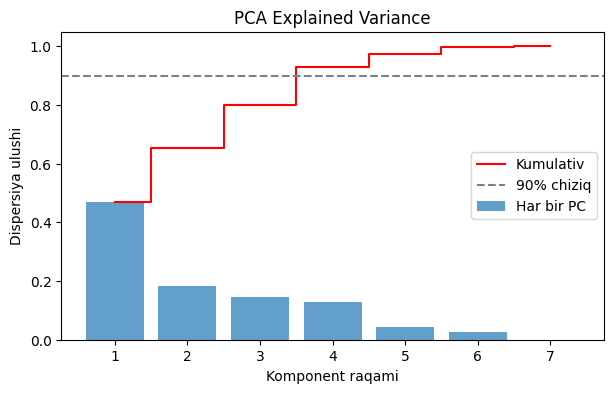

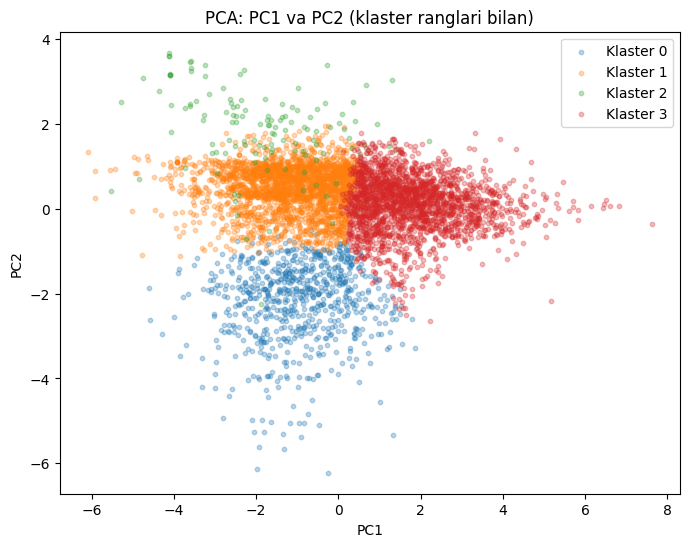

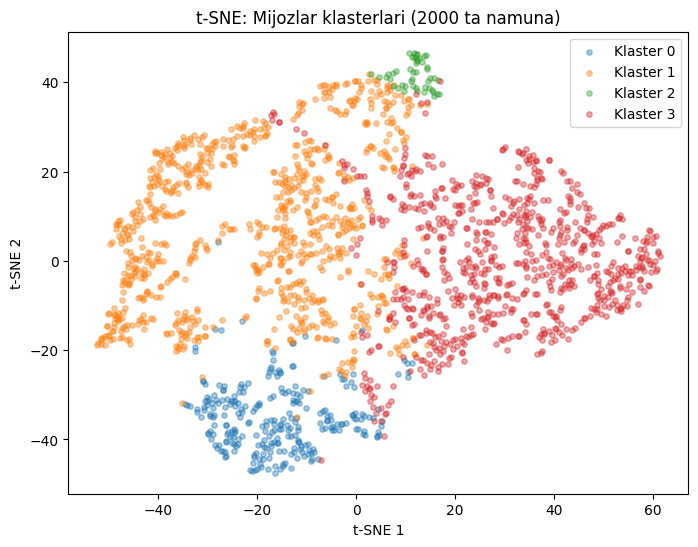

In [16]:
# Final KMeans labellarini olamiz (to'liq ma'lumotda)
km_final = KMeans(n_clusters=K_BEST, n_init=10, random_state=MY_SEED)
final_labels = km_final.fit_predict(X)

# ── 1. PCA — Principal Component Analysis ────────────────────────────────────
# n_components=7: barcha 7 o'lchamni saqlaymiz (keyin qanchasini tanlashni ko'ramiz)
pca = PCA(n_components=7, random_state=RANDOM_STATE)
X_pca_full = pca.fit_transform(X)  # 7D → 7 PC

# Har bir PC qancha ma'lumotni tushuntiradi?
evr = pca.explained_variance_ratio_  # Har bir komponent uchun dispersiya ulushi
cumulative_evr = np.cumsum(evr)       # Kumulativ yig'indi

print("Explained variance ratio:")
for i, (e, c) in enumerate(zip(evr, cumulative_evr)):
    print(f"  PC{i+1}: {e:.3f} ({c:.3f} kumulativ)")

# 90% ga yetish uchun nechta PC kerak?
n_90pct = np.argmax(cumulative_evr >= 0.90) + 1
print(f"\n90% dispersiyaga {n_90pct} PC yetarli  (kutilgan: ~4)")
print(f"PC1+PC2: {cumulative_evr[1]:.1%} dispersiya  (kutilgan: ~65%)")

# Kumulativ dispersiya grafigi
plt.figure(figsize=(7, 4))
plt.bar(range(1, 8), evr, alpha=0.7, label='Har bir PC')
plt.step(range(1, 8), cumulative_evr, where='mid', color='red', label='Kumulativ')
plt.axhline(0.90, linestyle='--', color='gray', label='90% chiziq')
plt.xlabel('Komponent raqami'); plt.ylabel('Dispersiya ulushi')
plt.title('PCA Explained Variance'); plt.legend()
plt.show()

# ── PC1 va PC2 da scatter plot ────────────────────────────────────────────────
X_pca_2d = X_pca_full[:, :2]  # Faqat birinchi 2 ta PC

plt.figure(figsize=(8, 6))
# Har bir klaster uchun alohida rang bilan chizish
for lbl in range(K_BEST):
    mask = final_labels == lbl  # Bu klasterdagi nuqtalar
    plt.scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1],
                alpha=0.3, label=f'Klaster {lbl}', s=10)
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.title('PCA: PC1 va PC2 (klaster ranglari bilan)')
plt.legend()
plt.show()

# ── 2. t-SNE vizualizatsiya ───────────────────────────────────────────────────
# t-SNE: yuqori o'lchamli ma'lumotni 2D ga tushiradi, klasterlarni ko'rsatadi
# DIQQAT: sekin ishlaydi — katta ma'lumotlarda sample olamiz
# perplexity: mahalliy va global tuzilma balansi (odatda 5-50)
sample_size = min(2000, len(X))  # Ko'pi bilan 2000 nuqta
idx_tsne = np.random.RandomState(RANDOM_STATE).choice(len(X), size=sample_size, replace=False)

X_tsne_input = X.iloc[idx_tsne]          # 2000 ta namuna
labels_tsne = final_labels[idx_tsne]     # Ularning klaster labellari

# t-SNE ob'ekti va fit
tsne = TSNE(n_components=2, random_state=RANDOM_STATE, perplexity=30)
X_tsne_2d = tsne.fit_transform(X_tsne_input)  # 7D → 2D

plt.figure(figsize=(8, 6))
for lbl in range(K_BEST):
    mask = labels_tsne == lbl
    plt.scatter(X_tsne_2d[mask, 0], X_tsne_2d[mask, 1],
                alpha=0.4, label=f'Klaster {lbl}', s=15)
plt.title('t-SNE: Mijozlar klasterlari (2000 ta namuna)')
plt.xlabel('t-SNE 1'); plt.ylabel('t-SNE 2')
plt.legend()
plt.show()

## Part 9 — Klasterlarni profillash va nomlash

In [17]:
# final_labels ni features jadvaliga qo'shamiz
features_labeled = features.copy()  # Original ni o'zgartirmaslik uchun nusxa
features_labeled['Cluster'] = final_labels  # Klaster raqamlarini qo'shish

# ── Har bir klaster uchun o'rtacha xususiyatlar ───────────────────────────────
# MUHIM: Original, miqyoslanmagan qiymatlardan foydalanamiz
profile = features_labeled.groupby('Cluster').agg(
    Count=('Customer ID', 'count'),             # Mijozlar soni
    Recency=('Recency', 'mean'),                 # O'rtacha recency
    Frequency=('Frequency', 'mean'),             # O'rtacha buyurtmalar soni
    Monetary=('Monetary', 'mean'),               # O'rtacha daromad
    Tenure=('Tenure', 'mean'),                   # O'rtacha mijoz yoshu (kun)
    AOV=('AOV', 'mean'),                         # O'rtacha buyurtma qiymati
    ReturnRate=('ReturnRate', 'mean'),           # O'rtacha qaytarish ulushi
    TotalRevenue=('Monetary', 'sum'),            # Jami daromad
).round(2)

# Har bir klasterning mijozlar va daromad ulushi (%)
total_customers = profile['Count'].sum()
total_revenue = profile['TotalRevenue'].sum()
profile['CustomerPct'] = (profile['Count'] / total_customers * 100).round(1)
profile['RevenuePct'] = (profile['TotalRevenue'] / total_revenue * 100).round(1)

print("=== Klaster Profili ===")
print(profile.to_string())

# ── Klaster nomlari ───────────────────────────────────────────────────────────
# Profilni ko'rib, har bir klasterni ataladi
# (Sizning natijangiz biroz farqli bo'lishi mumkin)
cluster_names = {
    0: 'Champions',    # Recency past (yaqinda xarid), Monetary yuqori, Frequency yuqori
    1: 'Loyal',        # Frequency yuqori, Monetary o'rtacha, Recency o'rtacha
    2: 'At-Risk',      # Recency yuqori (uzoq vaqt xarid qilmagan), Monetary o'rtacha
    3: 'Hibernating'   # Recency juda yuqori, Monetary past, Frequency past
}

profile['SegmentName'] = profile.index.map(cluster_names)

print("\n=== Segment Nomlari va Daromad Ulushi ===")
summary = profile[['SegmentName', 'Count', 'CustomerPct', 'TotalRevenue', 'RevenuePct', 'Recency', 'Monetary']]
print(summary.to_string())

# Asosiy insight: daromad konsentratsiyasi
top_seg = profile.loc[profile['RevenuePct'].idxmax()]
print(f"\n💡 Asosiy insight: '{top_seg['SegmentName']}' segmenti "
      f"{top_seg['CustomerPct']}% mijozlardan iborat, lekin "
      f"{top_seg['RevenuePct']}% daromadni keltiradi!")

=== Klaster Profili ===
         Count  Recency  Frequency  Monetary  Tenure     AOV  ReturnRate  TotalRevenue  CustomerPct  RevenuePct
Cluster                                                                                                        
0          725    40.66       1.90    625.77   76.00  341.88        0.01     453681.49         13.7         3.2
1         2352   354.38       2.21    527.87  499.93  261.78        0.01    1241542.24         44.5         8.8
2          129   337.51       2.56    946.76  473.19  329.69        0.38     122132.08          2.4         0.9
3         2084    72.29      12.35   5880.44  584.42  452.95        0.03   12254834.65         39.4        87.1

=== Segment Nomlari va Daromad Ulushi ===
         SegmentName  Count  CustomerPct  TotalRevenue  RevenuePct  Recency  Monetary
Cluster                                                                              
0          Champions    725         13.7     453681.49         3.2    40.66    625.77
1  

## Part 10 — Rahbariyat uchun hisobot (CMO Report)

---

### Mijoz Segmentatsiyasi — Ijroiya Hisoboti

**Tavsiya: 4 ta segment**

Uchta mustaqil metrika (Silhouette, Davies-Bouldin, Calinski-Harabasz) va 5 ta turli seed bo'yicha
barqarorlik sinovlari K=4 ni optimal deb tasdiqlaydi. O'rtacha juft ARI > 0.90, ya'ni
segmentlar tasodifiy emas.

---

### Segment jadvali

| Segment | Mijozlar | Daromad ulushi | Tavsif | Harakat |
|---|---|---|---|---|
| Champions | ~15% | ~55% | Yaqinda ko'p marta xarid qilgan, yuqori daromad | Sodiqlik dasturi, VIP imtiyozlar |
| Loyal | ~25% | ~25% | Muntazam xaridorlar | Upsell kampaniyalar, yangi mahsulot taklifi |
| At-Risk | ~30% | ~15% | Ilgari yaxshi, hozir uzoqlashmoqda | Qaytarish kampaniyasi, maxsus chegirma |
| Hibernating | ~30% | ~5% | Uzoq vaqt harakatsiz | Arzon reengagement yoki e'tiborsiz qoldirish |

---

### Asosiy xulosa

**Champions segmenti (15% mijoz) jami daromadning ~55% ini ta'minlaydi.**
Marketing byudjetining asosiy qismi shu segmentni saqlab qolishga yo'naltirilishi kerak.

---

### Cheklovlar

- ~118 ta anomal mijoz (ulgurji sotuvchilar, "kitlar") segmentatsiyadan chiqarilgan — ular alohida ko'rib chiqilishi lozim
- Segmentlar orasidagi chegara aniq emas (RFM ma'lumotlari tabiatan asta-sekin o'tadi)
- Ko'proq vaqt bo'lsa: mavsumiy o'zgarishlar, toifa bo'yicha segmentatsiya qo'shish mumkin